# Full-Data Model Prediction Maps

Train MLP, DT, and mGBDT once on the full configured dataset, then map the actual target and each model prediction using real latitude/longitude.

## Config

In [12]:
from pathlib import Path
import os
import sys
import random
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import folium
import branca.colormap as cm
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "mapping":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "test":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path(r"C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.dataload import (
    HOUSING_PATH,
    PRICE_PATH,
    PRICE_PER_SQFT_PATH,
    drop_addr,
    drop_coord,
    load_df,
    split_X_y,
    target_encode,
)
from metrics.adjusted_r2 import adjusted_r2
from metrics.mae import mae
from metrics.mape import mape
from metrics.mse import rmse
from metrics.r2_score import r2_score
from models import TrainConfig
from models.decision_tree import DecisionTree, DecisionTreeConfig
from models.mlp import MLP, MLPConfig
from models.mgbdt_ours import MGBDTModel, mGBDTConfig

# Choose one: "price" or "price_per_sqft".
target = ["price", "price_per_sqft"]
TARGET_NAME = target[1]

# Same feature ablation switches as k-fold notebooks.
DROP_ADDRESS = 1
DROP_COORD = 1

SEED = 42
MODEL_ORDER = ["mlp", "dt", "mgbdt"]

MAPPING_DIR = PROJECT_ROOT / "test" / "mapping"
MAPPING_DIR.mkdir(parents=True, exist_ok=True)

MINMAX_COLS = [
    "x", "y", "z", "condition", "age", "bedrooms",
    "bathrooms", "floors", "view",
]

ZSCORE_COLS = [
    "sqft_living", "sqft_above", "sqft_basement",
    "log_sqft_lot", "city", "zipcode",
]

DT_HPARAMS = {
    "max_depth": 6,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
}

MLP_HPARAMS = {
    "hidden_dims": [32, 32],
    "dropout": 0.0,
    "use_batch_norm": True,
    "epochs": 50,
    "lr": 1e-2,
    "batch_size": 16,
}

MGBDT_HPARAMS = {
    "learning_rate": 0.1,
    "max_depth": 5,
    "num_boost_round": 5,
    "target_lr": 0.5,
    "epsilon": 0.3,
    "force_no_parallel": True,
    "epochs": 50,
    "batch_size": 16,
    "layer_configs": [("tp_layer", "xgb")],
}

HPARAMS = {
    "mlp": MLP_HPARAMS,
    "dt": DT_HPARAMS,
    "mgbdt": MGBDT_HPARAMS,
}

ZSCORE_CLIP = 3.0
POINT_RADIUS = 2
POINT_OPACITY = 0.65
ZSCORE_COLORS = ["#440154", "#3b528b", "#21918c", "#5ec962", "#fde725"]
ZSCORE_CMAP = LinearSegmentedColormap.from_list("viridis_zscore", ZSCORE_COLORS)

CONFIG = {
    "project_root": str(PROJECT_ROOT),
    "target_name": TARGET_NAME,
    "drop_address": DROP_ADDRESS,
    "drop_coord": DROP_COORD,
    "seed": SEED,
    "model_order": MODEL_ORDER,
    "mapping_dir": str(MAPPING_DIR.relative_to(PROJECT_ROOT)),
    "hparams": HPARAMS,
}

CONFIG

{'project_root': 'c:\\Career\\UNIST\\4-1\\Machine Learning\\Project\\house-price-regressor',
 'target_name': 'price_per_sqft',
 'drop_address': 1,
 'drop_coord': 1,
 'seed': 42,
 'model_order': ['mlp', 'dt', 'mgbdt'],
 'mapping_dir': 'test\\mapping',
 'hparams': {'mlp': {'hidden_dims': [32, 32],
   'dropout': 0.0,
   'use_batch_norm': True,
   'epochs': 50,
   'lr': 0.01,
   'batch_size': 16},
  'dt': {'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 2},
  'mgbdt': {'learning_rate': 0.1,
   'max_depth': 5,
   'num_boost_round': 5,
   'target_lr': 0.5,
   'epsilon': 0.3,
   'force_no_parallel': True,
   'epochs': 50,
   'batch_size': 16,
   'layer_configs': [('tp_layer', 'xgb')]}}}

## Training

In [13]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def target_path(target_name: str) -> str:
    if target_name == "price":
        return PRICE_PATH
    if target_name == "price_per_sqft":
        return PRICE_PER_SQFT_PATH
    raise ValueError("TARGET_NAME must be 'price' or 'price_per_sqft'")


def existing_cols(df: pd.DataFrame, cols: list[str]) -> list[str]:
    return [col for col in cols if col in df.columns]


def preprocess_full(X_raw, y_fit, model_name: str):
    X = X_raw.copy()

    for col in ["city", "zipcode"]:
        if col in X.columns:
            X[col], _ = target_encode(X, y_fit, X, col)

    mm_cols = existing_cols(X, MINMAX_COLS)
    if mm_cols:
        scaler_mm = MinMaxScaler()
        X[mm_cols] = scaler_mm.fit_transform(X[mm_cols])

    z_cols = existing_cols(X, ZSCORE_COLS)
    if z_cols:
        scaler_z = StandardScaler()
        X[z_cols] = scaler_z.fit_transform(X[z_cols])

    if model_name == "dt" and "age" in X.columns:
        X["age_bin"] = pd.cut(X["age"], bins=5, labels=[0, 1, 2, 3, 4]).astype(float)

    if DROP_ADDRESS:
        X = drop_addr(X)
    if DROP_COORD:
        X = drop_coord(X)

    return X


def build_model(model_name: str, input_dim: int):
    if model_name == "mlp":
        hp = MLP_HPARAMS
        return MLP(
            MLPConfig(
                model="mlp",
                input_dim=input_dim,
                hidden_dims=hp["hidden_dims"],
                output_dim=1,
                dropout=hp["dropout"],
                use_batch_norm=hp["use_batch_norm"],
            )
        )

    if model_name == "dt":
        return DecisionTree(DecisionTreeConfig(model="dt", **DT_HPARAMS))

    if model_name == "mgbdt":
        hp = MGBDT_HPARAMS
        cfg = mGBDTConfig(
            model="mgbdt",
            input_size=input_dim,
            output_size=1,
            task="regression",
            learning_rate=hp["learning_rate"],
            max_depth=hp["max_depth"],
            num_boost_round=hp["num_boost_round"],
            target_lr=hp["target_lr"],
            epsilon=hp["epsilon"],
            force_no_parallel=hp["force_no_parallel"],
        )
        return MGBDTModel(cfg, layer_configs=hp["layer_configs"])

    raise ValueError(f"Unknown model: {model_name}")


def train_config_for(model_name: str, X_train, y_train_fit):
    if model_name == "mlp":
        hp = MLP_HPARAMS
        return TrainConfig(X=X_train, y=y_train_fit, epochs=hp["epochs"], lr=hp["lr"], batch_size=hp["batch_size"], verbose=False)
    if model_name == "dt":
        return TrainConfig(X=X_train, y=y_train_fit, epochs=1, lr=0.0, batch_size=None, verbose=False)
    if model_name == "mgbdt":
        hp = MGBDT_HPARAMS
        return TrainConfig(X=X_train, y=y_train_fit, epochs=hp["epochs"], lr=hp["learning_rate"], batch_size=hp["batch_size"], verbose=False)
    raise ValueError(f"Unknown model: {model_name}")


def metric_dict(y_true, y_pred, n_features: int):
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "R2": r2,
        "Adjusted_R2": adjusted_r2(y_true, y_pred, n_features),
        "Accuracy": r2 * 100,
    }


set_seed(SEED)
df = load_df(target_path(TARGET_NAME))
X_all, y_all = split_X_y(df, "price")

target_scaler = None
y_fit = y_all.copy()
if TARGET_NAME == "price":
    target_scaler = MinMaxScaler()
    y_fit = pd.Series(
        target_scaler.fit_transform(y_all.values.reshape(-1, 1)).ravel(),
        index=y_all.index,
    )

print("target:", TARGET_NAME)
print("drop_address:", DROP_ADDRESS)
print("drop_coord:", DROP_COORD)
print("X shape:", X_all.shape)

target: price_per_sqft
drop_address: 1
drop_coord: 1
X shape: (3977, 17)


In [14]:
models = {}
predictions = {}
rows = []

for model_name in MODEL_ORDER:
    print(f"\n===== {model_name.upper()} full-data training start =====")
    set_seed(SEED)

    X_train = preprocess_full(X_all, y_fit, model_name)
    model = build_model(model_name, X_train.shape[1])

    start = time.perf_counter()
    model.fit(train_config_for(model_name, X_train, y_fit))
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    pred_fit = np.asarray(model.predict(X_train)).reshape(-1)
    predict_seconds = time.perf_counter() - start

    if target_scaler is not None:
        pred = target_scaler.inverse_transform(pred_fit.reshape(-1, 1)).ravel()
    else:
        pred = pred_fit

    models[model_name] = model
    predictions[model_name] = pred

    row = {
        "model": model_name,
        "target": TARGET_NAME,
        "drop_address": DROP_ADDRESS,
        "drop_coord": DROP_COORD,
        "n_rows": len(X_train),
        "n_features": X_train.shape[1],
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
    }
    row.update(metric_dict(y_all, pred, X_train.shape[1]))
    rows.append(row)

    print(f"fit_seconds={fit_seconds:.4f}, predict_seconds={predict_seconds:.4f}")

results_df = pd.DataFrame(rows)
results_df


===== MLP full-data training start =====


C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)
C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [17:25:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[ 2026-06-05 17:25:09,292][mgbdt.log] [epoch=0/50][train] loss=78185.068142
[ 2026-06-05 17:25:09,319][mgbdt.log] [epoch=1/50][train] loss=32282.073925
[ 2026-06-05 17:25:09,347][mgbdt.log] [epoch=2/50][train] loss=15904.561227
[ 2026-06-05 17:25:09,374][mgbdt.log] [epoch=3/50][train] loss=9891.651999


[MLP.fit] Execution time: 25.6028 sec
[MLP.predict] Execution time: 0.0020 sec
fit_seconds=25.6036, predict_seconds=0.0021

===== DT full-data training start =====
[DecisionTree.fit] Execution time: 0.0183 sec
[DecisionTree.predict] Execution time: 0.0023 sec
fit_seconds=0.0184, predict_seconds=0.0024

===== MGBDT full-data training start =====


[ 2026-06-05 17:25:09,401][mgbdt.log] [epoch=4/50][train] loss=7599.518733
[ 2026-06-05 17:25:09,429][mgbdt.log] [epoch=5/50][train] loss=6627.825497
[ 2026-06-05 17:25:09,457][mgbdt.log] [epoch=6/50][train] loss=6127.640935
[ 2026-06-05 17:25:09,487][mgbdt.log] [epoch=7/50][train] loss=5845.197888
[ 2026-06-05 17:25:09,517][mgbdt.log] [epoch=8/50][train] loss=5672.710083
[ 2026-06-05 17:25:09,550][mgbdt.log] [epoch=9/50][train] loss=5530.978627
[ 2026-06-05 17:25:09,582][mgbdt.log] [epoch=10/50][train] loss=5422.549158
[ 2026-06-05 17:25:09,616][mgbdt.log] [epoch=11/50][train] loss=5322.081971
[ 2026-06-05 17:25:09,646][mgbdt.log] [epoch=12/50][train] loss=5234.253960
[ 2026-06-05 17:25:09,678][mgbdt.log] [epoch=13/50][train] loss=5096.459140
[ 2026-06-05 17:25:09,710][mgbdt.log] [epoch=14/50][train] loss=5007.548906
[ 2026-06-05 17:25:09,741][mgbdt.log] [epoch=15/50][train] loss=4915.748051
[ 2026-06-05 17:25:09,776][mgbdt.log] [epoch=16/50][train] loss=4808.655771
[ 2026-06-05 17:25

[MGBDTModel.fit] Execution time: 2.0534 sec
[MGBDTModel.predict] Execution time: 0.0081 sec
fit_seconds=2.0537, predict_seconds=0.0082


,model,target,drop_address,drop_coord,n_rows,n_features,fit_seconds,predict_seconds,MAE,RMSE,MAPE,R2,Adjusted_R2,Accuracy
0,mlp,price_per_sqft,1,1,3977,12,25.603567,0.002104,65.422737,84.247126,30.245145,0.330300,0.328273,33.030020
1,dt,price_per_sqft,1,1,3977,13,0.018425,0.002392,64.792810,83.537336,30.305878,0.341537,0.339377,34.153722
2,mgbdt,price_per_sqft,1,1,3977,12,2.053656,0.008214,42.590062,54.925721,19.719761,0.715343,0.714482,71.534323


## Evaluation

In [15]:
display_cols = [
    "model", "target", "drop_address", "drop_coord", "n_rows", "n_features",
    "fit_seconds", "predict_seconds", "MAE", "RMSE", "MAPE", "R2", "Adjusted_R2", "Accuracy",
]

print("[Full-data training table]")
print(f"target dataset: {TARGET_NAME}")
print(f"drop_address: {DROP_ADDRESS}")
print(f"drop_coord: {DROP_COORD}")
print(f"model order: {MODEL_ORDER}")
results_df[display_cols]

[Full-data training table]
target dataset: price_per_sqft
drop_address: 1
drop_coord: 1
model order: ['mlp', 'dt', 'mgbdt']


,model,target,drop_address,drop_coord,n_rows,n_features,fit_seconds,predict_seconds,MAE,RMSE,MAPE,R2,Adjusted_R2,Accuracy
0,mlp,price_per_sqft,1,1,3977,12,25.603567,0.002104,65.422737,84.247126,30.245145,0.330300,0.328273,33.030020
1,dt,price_per_sqft,1,1,3977,13,0.018425,0.002392,64.792810,83.537336,30.305878,0.341537,0.339377,34.153722
2,mgbdt,price_per_sqft,1,1,3977,12,2.053656,0.008214,42.590062,54.925721,19.719761,0.715343,0.714482,71.534323


## Scatter Visualization

In [16]:
def aligned_coordinate_df(target_name: str):
    raw = pd.read_csv(HOUSING_PATH)
    raw = raw[raw["price"] > 0].copy()

    if target_name == "price_per_sqft":
        raw["actual"] = raw["price"] / raw["sqft_living"]
    else:
        raw["actual"] = raw["price"]

    cap = raw["actual"].quantile(0.995)
    raw = raw[raw["actual"] <= cap].copy()
    raw = raw.dropna(subset=["lat", "long"]).copy()
    raw = raw.reset_index(drop=True)

    if len(raw) != len(y_all):
        raise ValueError(f"Coordinate rows ({len(raw)}) do not match training rows ({len(y_all)}).")

    raw["actual"] = y_all.reset_index(drop=True).values
    return raw[["actual", "lat", "long"]].copy()


map_df = aligned_coordinate_df(TARGET_NAME)
for model_name in MODEL_ORDER:
    map_df[f"pred_{model_name}"] = predictions[model_name]

actual_mean = map_df["actual"].mean()
actual_std = map_df["actual"].std(ddof=0)

print("[Mapping data]")
print(f"target dataset: {TARGET_NAME}")
print(f"drop_address: {DROP_ADDRESS}")
print(f"drop_coord: {DROP_COORD}")
print(f"rows: {len(map_df):,}")
print(f"z-score reference mean: {actual_mean:,.4f}")
print(f"z-score reference std: {actual_std:,.4f}")

map_df.head()

[Mapping data]
target dataset: price_per_sqft
drop_address: 1
drop_coord: 1
rows: 3,977
z-score reference mean: 259.9941
z-score reference std: 102.9473


,actual,lat,long,pred_mlp,pred_dt,pred_mgbdt
0,280.597015,47.696999,-122.350076,300.695007,322.782611,274.240753
1,225.988701,47.629478,-121.898818,213.739655,245.603444,224.344681
2,307.962586,47.538362,-121.980874,317.901154,216.412555,301.038147
3,324.649299,47.697921,-122.366360,341.927856,315.548581,335.351227
4,179.705882,47.505311,-122.372137,210.146088,217.099657,182.708084


[Actual scatter]
target dataset: price_per_sqft
drop_address: 1
drop_coord: 1
rows: 3,977


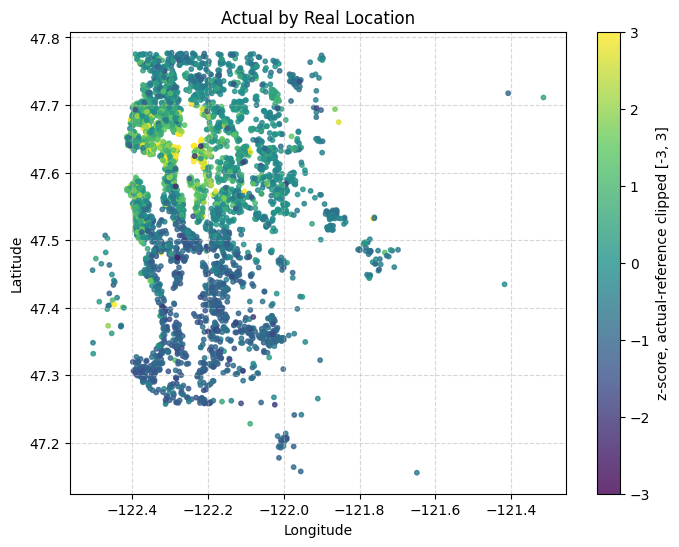

In [17]:
def add_zscore_columns(df: pd.DataFrame, value_col: str):
    out = df.copy()
    out["value_zscore"] = (out[value_col] - actual_mean) / actual_std
    out["value_zscore_clipped"] = out["value_zscore"].clip(-ZSCORE_CLIP, ZSCORE_CLIP)
    return out


def plot_prediction_scatter(df: pd.DataFrame, value_col: str, title: str):
    plot_df = add_zscore_columns(df, value_col)

    print(f"[{title} scatter]")
    print(f"target dataset: {TARGET_NAME}")
    print(f"drop_address: {DROP_ADDRESS}")
    print(f"drop_coord: {DROP_COORD}")
    print(f"rows: {len(plot_df):,}")

    ax = plot_df.plot(
        kind="scatter",
        x="long",
        y="lat",
        c="value_zscore_clipped",
        cmap=ZSCORE_CMAP,
        vmin=-ZSCORE_CLIP,
        vmax=ZSCORE_CLIP,
        colorbar=True,
        figsize=(8, 6),
        alpha=0.8,
        s=10,
    )

    ax.set_title(f"{title} by Real Location")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.collections[0].colorbar.set_label("z-score, actual-reference clipped [-3, 3]")

    plt.show()


plot_prediction_scatter(map_df, "actual", "Actual")

[MLP Prediction scatter]
target dataset: price_per_sqft
drop_address: 1
drop_coord: 1
rows: 3,977


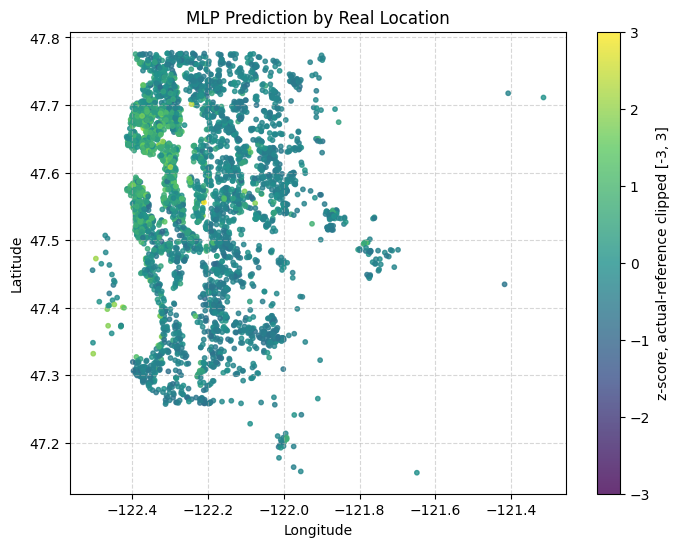

In [18]:
plot_prediction_scatter(map_df, "pred_mlp", "MLP Prediction")

[DT Prediction scatter]
target dataset: price_per_sqft
drop_address: 1
drop_coord: 1
rows: 3,977


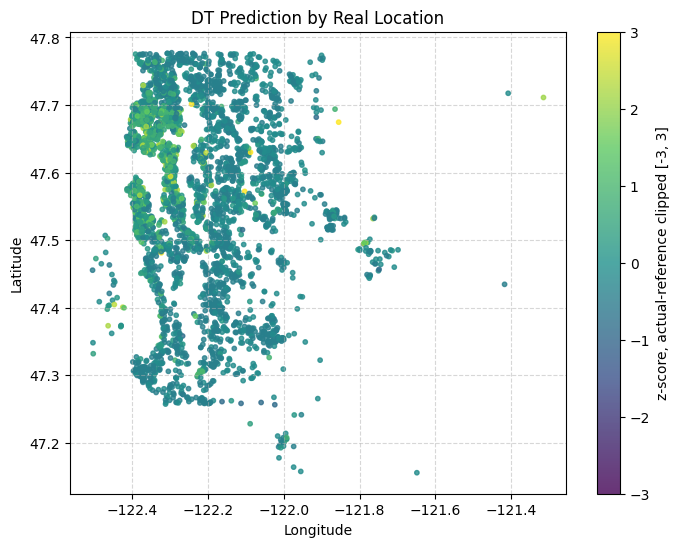

In [19]:
plot_prediction_scatter(map_df, "pred_dt", "DT Prediction")

[mGBDT Prediction scatter]
target dataset: price_per_sqft
drop_address: 1
drop_coord: 1
rows: 3,977


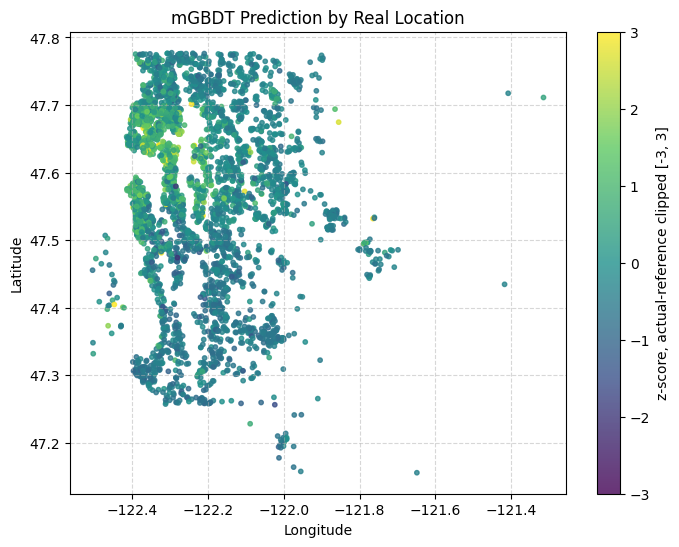

In [20]:
plot_prediction_scatter(map_df, "pred_mgbdt", "mGBDT Prediction")